# Machine Learning
## Logistic Regression Baseline
Dataset: Breast Cancer Wisconsin
Langkah:
1. Eksplorasi dataset
2. Periksa maslaah yang potensial(perlu preproses?)
3. Train dengan model linear (log reg)
4. Evaluasi performa


## 1. Import Libraries

In [59]:
pip install ucimlrepo

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Load Dataset

In [61]:
# Load Dataset
data = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = data.data.features
y = data.data.targets

# Ubah nama kolom asli bawaan ('income') menjadi 'target'
y.columns = ["target"]

print('Feature shape:', X.shape)
X.head()

Feature shape: (48842, 14)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


## 3️ Basic Dataset Information

In [62]:

print("Shape:", X.shape)
print("\nClass distribution:")

y = y.copy()
y['target'] = y['target'].str.replace('.', '', regex=False)

print(y.value_counts())


Shape: (48842, 14)

Class distribution:
target
<=50K     37155
>50K      11687
Name: count, dtype: int64


## 3. Basic Dataset Diagnosis

In [63]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
dtypes: int64(6), object(8)
memory usage: 5.2+ MB


In [64]:
X.isnull().sum().sum()

np.int64(2203)

### Class Distribution

In [65]:
y.value_counts()

,count
target,
<=50K,37155
>50K,11687


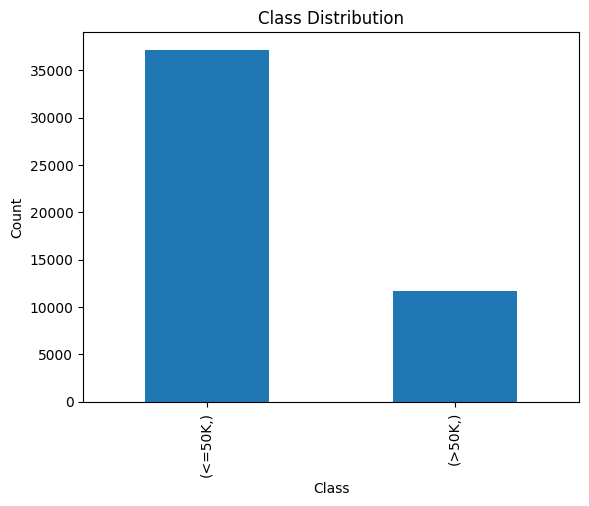

In [66]:
plt.figure()
y.value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

diksusi:
- apakah dataset seimbang kelasnya?
- apakah ada missing values?
- apakah ada fitur numerik atau kategorikal?


## 4. Train-Test Split

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training shape:', X_train.shape)
print('Test shape:', X_test.shape)

Training shape: (39073, 14)
Test shape: (9769, 14)



mengapa split sebelum preproses?


## 5. Feature Scaling

In [68]:
# 1. Automatically separate numeric and categorical columns
numeric_columns = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = X_train.select_dtypes(include=['object', 'category']).columns

# 2. Build the preprocessor to scale numbers and encode text
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_columns)
    ])

# 3. Fit and transform your data safely
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

X_train_scaled[:5]

array([[-0.12009008,  0.02952118,  1.13821044, -0.14407503, -0.21633213,
        -0.84483496,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  1.        ,  0.        ,  0. 

## 6. Train Logistic Regression

In [69]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train.values.ravel())

LogisticRegression(max_iter=1000)

## 7. Model Coefficients

In [70]:
# 1. Ambil nama fitur terbaru dari preprocessor
nama_fitur_baru = preprocessor.get_feature_names_out()

# 2. Pasangkan bobot model dengan nama fitur barunya
coefficients = pd.Series(model.coef_[0], index=nama_fitur_baru)

# 3. Tampilkan 5 fitur dengan bobot positif terbesar
print("Fitur paling berpengaruh positif (>50K):")
print(coefficients.sort_values(ascending=False).head())

# 4. (Opsional) Tampilkan 5 fitur dengan bobot negatif terbesar
print("\nFitur paling berpengaruh negatif (<=50K):")
print(coefficients.sort_values(ascending=True).head())

Fitur paling berpengaruh positif (>50K):
num__capital-gain                         2.277669
cat__marital-status_Married-civ-spouse    1.390367
cat__marital-status_Married-AF-spouse     1.228447
cat__native-country_France                1.014298
cat__relationship_Wife                    0.956967
dtype: float64

Fitur paling berpengaruh negatif (<=50K):
cat__occupation_Priv-house-serv     -1.559265
cat__native-country_South           -1.356570
cat__native-country_Columbia        -1.169538
cat__marital-status_Never-married   -1.127380
cat__relationship_Own-child         -0.967269
dtype: float64


In [71]:
intercept = model.intercept_
intercept

array([-1.65455131])

Fitur mana yag kelihatan paling penting?


In [72]:
# Ambil intercept (b) dan coefficients (w)
b = model.intercept_[0]
w = model.coef_[0]

# Ambil satu contoh data, sample ke 0 (pertama)
sample_data = X_test_scaled[1]

# Hitung z (Linear Representation)
# z = b + (w1*x1 + w2*x2 + ...)
z = b + np.dot(w, sample_data)

print(f"Skor Linear (z): {z}")

Skor Linear (z): -2.412626572888839


In [73]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

probabilitas_manual = sigmoid(z) #berdasarkan nilai dari model linear, berapa probabilitas (sigmoid) dari sample tsb?
#jika prob mendekati 0, berarti kelas 0, jika mendekati 1, maka kelas 1.

probabilitas_sklearn = model.predict_proba(X_test_scaled)[1] #  fungsi bawaan sklearn, menunjukkan berapa probabilitas unuk kelas 0 dan 1 (untuk kasus ini)
print(probabilitas_manual)
print(probabilitas_sklearn)
print(np.round(probabilitas_sklearn, 3))


0.08221491083723555
[0.91778509 0.08221491]
[0.918 0.082]


## 8. Prediction

In [74]:
y_pred = model.predict(X_test_scaled)
y_pred[:10]

array(['<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '>50K',
       '<=50K', '<=50K', '<=50K'], dtype=object)

## 9. Evaluation

In [75]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.8517760262053434


In [76]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7431
        >50K       0.73      0.60      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.77      0.78      9769
weighted avg       0.85      0.85      0.85      9769



In [77]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[6918,  513],
       [ 935, 1403]])

## 10. Soal Refleksi
1. Mengapa kita perlu menskalakan fitur?
2. Apa yang terjadi jika kita skip scaling?
3. fitur mana ynag punya koefisien paling besar?
4. Bagaimana kita bisa mengimprove model?
